# 03 - Deep Learning model: BiLSTM (from scratch)
**NLP Deliverable 2 — modern ML approach #1**

A Bidirectional LSTM tagger trained **from scratch** in PyTorch with word embeddings
learned from the training data. Unlike the CRF, no handcrafted features are used: the
model learns its own representations.

Saved artifacts (used by `05_reproduce_results.ipynb`):
`fitted_models/bilstm_model.pth` and `fitted_models/dl_mappings.pkl`.

> Colab-friendly: auto-detects **cuda / mps / cpu**.

In [20]:
# === Setup (works locally and on Google Colab) ===
import sys, os
IN_COLAB = 'google.colab' in sys.modules
DATA_DIR = '.' if IN_COLAB else '../nlp_d2_data'
FITTED_DIR = 'fitted_models'
os.makedirs(FITTED_DIR, exist_ok=True)

import warnings; warnings.filterwarnings('ignore')
import pickle
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
sns.set_theme(style='whitegrid')

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## 1. Load data

In [21]:
def load_data(path):
    df = pd.read_csv(path)
    df['words'] = df['words'].astype(str)
    df['tags'] = df['tags'].fillna('O').astype(str)
    df['sentence_id'] = df['sentence_id'].astype(int)
    return [list(zip(g['words'].tolist(), g['tags'].tolist()))
            for _, g in df.groupby('sentence_id', sort=True)]

train_sents = load_data(os.path.join(DATA_DIR, 'train_data_ner.csv'))
test_sents  = load_data(os.path.join(DATA_DIR, 'test_data_ner.csv'))
print(f'train: {len(train_sents)} | test: {len(test_sents)}')

train: 38366 | test: 38367


## 2. Vocabulary and tag mappings

In [22]:
word_to_ix = {'<PAD>': 0, '<UNK>': 1}
tag_to_ix  = {'<PAD>': 0}
for sent in train_sents:
    for w, t in sent:
        if w not in word_to_ix: word_to_ix[w] = len(word_to_ix)
        if t not in tag_to_ix:  tag_to_ix[t]  = len(tag_to_ix)
ix_to_tag = {v: k for k, v in tag_to_ix.items()}

# Hyper-parameters (also stored so the architecture can be rebuilt at load time)
HP = dict(embedding_dim=200, hidden_dim=128, max_len=60,
          batch_size=64, epochs=50, lr=1e-3, dropout=0.3)

with open(os.path.join(FITTED_DIR, 'dl_mappings.pkl'), 'wb') as fh:
    pickle.dump({'word_to_ix': word_to_ix, 'tag_to_ix': tag_to_ix,
                 'ix_to_tag': ix_to_tag, 'hp': HP}, fh)
print(f'vocab: {len(word_to_ix)} | tags: {len(tag_to_ix)}')

vocab: 31981 | tags: 18


## 3. Dataset and model

In [23]:
class NERDataset(Dataset):
    def __init__(self, sents, w2i, t2i, max_len):
        self.sents, self.w2i, self.t2i, self.max_len = sents, w2i, t2i, max_len
    def __len__(self):
        return len(self.sents)
    def __getitem__(self, idx):
        sent = self.sents[idx]
        X = [self.w2i.get(w, self.w2i['<UNK>']) for w, _ in sent][:self.max_len]
        y = [self.t2i[t] for _, t in sent][:self.max_len]
        pad = self.max_len - len(X)
        X = X + [0]*pad
        y = y + [0]*pad
        return torch.tensor(X), torch.tensor(y)

class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, tagset_size)
    def forward(self, x):
        e = self.dropout(self.embedding(x))
        h, _ = self.lstm(e)
        return self.fc(self.dropout(h))

## 4. Training

In [24]:
train_loader = DataLoader(NERDataset(train_sents, word_to_ix, tag_to_ix, HP['max_len']),
                          batch_size=HP['batch_size'], shuffle=True)

model = BiLSTMTagger(len(word_to_ix), len(tag_to_ix),
                     HP['embedding_dim'], HP['hidden_dim'], HP['dropout']).to(device)
optimizer = optim.Adam(model.parameters(), lr=HP['lr'])
criterion = nn.CrossEntropyLoss(ignore_index=0)   # ignore <PAD>

model.train()
for epoch in range(HP['epochs']):
    total = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out.view(-1, out.shape[-1]), yb.view(-1))
        loss.backward(); optimizer.step()
        total += loss.item()
    print(f'Epoch {epoch+1}/{HP["epochs"]} - loss {total/len(train_loader):.4f}')

torch.save(model.state_dict(), os.path.join(FITTED_DIR, 'bilstm_model.pth'))
print('Saved fitted_models/bilstm_model.pth')

Epoch 1/50 - loss 0.4357
Epoch 2/50 - loss 0.1960
Epoch 3/50 - loss 0.1531
Epoch 4/50 - loss 0.1302
Epoch 5/50 - loss 0.1149
Epoch 6/50 - loss 0.1040
Epoch 7/50 - loss 0.0954
Epoch 8/50 - loss 0.0886
Epoch 9/50 - loss 0.0824
Epoch 10/50 - loss 0.0774
Epoch 11/50 - loss 0.0729
Epoch 12/50 - loss 0.0691
Epoch 13/50 - loss 0.0663
Epoch 14/50 - loss 0.0628
Epoch 15/50 - loss 0.0600
Epoch 16/50 - loss 0.0573
Epoch 17/50 - loss 0.0549
Epoch 18/50 - loss 0.0526
Epoch 19/50 - loss 0.0504
Epoch 20/50 - loss 0.0487
Epoch 21/50 - loss 0.0475
Epoch 22/50 - loss 0.0457
Epoch 23/50 - loss 0.0442
Epoch 24/50 - loss 0.0425
Epoch 25/50 - loss 0.0416
Epoch 26/50 - loss 0.0400
Epoch 27/50 - loss 0.0390
Epoch 28/50 - loss 0.0381
Epoch 29/50 - loss 0.0370
Epoch 30/50 - loss 0.0355
Epoch 31/50 - loss 0.0351
Epoch 32/50 - loss 0.0343
Epoch 33/50 - loss 0.0336
Epoch 34/50 - loss 0.0326
Epoch 35/50 - loss 0.0319
Epoch 36/50 - loss 0.0310
Epoch 37/50 - loss 0.0307
Epoch 38/50 - loss 0.0301
Epoch 39/50 - loss 0.

## 5. Evaluation

In [25]:
@torch.no_grad()
def predict(model, sents):
    model.eval()
    preds = []
    for sent in sents:
        ids = [word_to_ix.get(w, word_to_ix['<UNK>']) for w, _ in sent]
        x = torch.tensor(ids).unsqueeze(0).to(device)
        out = model(x)
        p = out.argmax(-1).squeeze(0).tolist()
        preds.append([ix_to_tag.get(i, 'O') for i in p])
    return preds

def flatten(seq): return [x for sub in seq for x in sub]
def non_o_accuracy(yt, yp):
    yt, yp = flatten(yt), flatten(yp)
    idx = [k for k, t in enumerate(yt) if t != 'O']
    return accuracy_score([yt[k] for k in idx], [yp[k] for k in idx])
def weighted_f1(yt, yp):
    yt, yp = flatten(yt), flatten(yp)
    labels = sorted(set(yt) - {'O', '<PAD>'})
    return f1_score(yt, yp, average='weighted', labels=labels, zero_division=0)

y_train = [[t for _, t in s] for s in train_sents]
y_test  = [[t for _, t in s] for s in test_sents]
yp_train = predict(model, train_sents)
yp_test  = predict(model, test_sents)

print(f"Train non-O accuracy: {non_o_accuracy(y_train, yp_train):.4f} | F1: {weighted_f1(y_train, yp_train):.4f}")
print(f"Test  non-O accuracy: {non_o_accuracy(y_test,  yp_test):.4f} | F1: {weighted_f1(y_test,  yp_test):.4f}")

Train non-O accuracy: 0.9890 | F1: 0.9873
Test  non-O accuracy: 0.5175 | F1: 0.5223


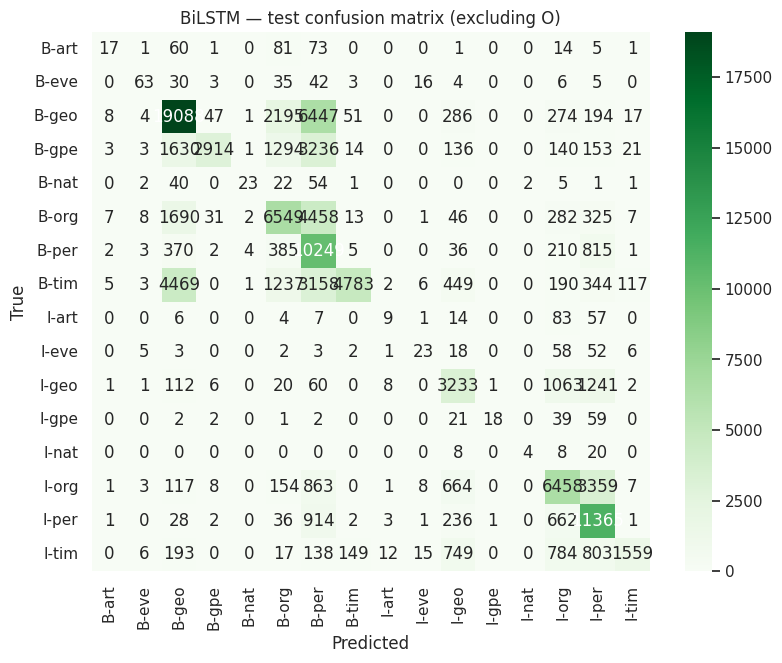

In [26]:
yt, yp = flatten(y_test), flatten(yp_test)
labels = sorted(set(yt) - {'O', '<PAD>'})
cm = confusion_matrix(yt, yp, labels=labels)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title('BiLSTM — test confusion matrix (excluding O)')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.show()

## 6. TINY TEST

In [27]:
tiny_sents = load_data(os.path.join(DATA_DIR, 'tiny_test.csv'))
y_tiny = [[t for _, t in s] for s in tiny_sents]
yp_tiny = predict(model, tiny_sents)
print('=== TINY TEST — BiLSTM ===')
for s, pred in zip(tiny_sents, yp_tiny):
    print(' '.join(f'{w}/{t}' for (w, _), t in zip(s, pred)))
print(f'\nTiny-test accuracy (non-O): {non_o_accuracy(y_tiny, yp_tiny):.4f}')

=== TINY TEST — BiLSTM ===
The/O programmers/O from/O Barcelona/B-geo might/O write/O a/O sentence/O without/O a/O spell/B-geo checker/I-org ./O
The/O programmers/O from/O Barchelona/B-geo cannot/I-geo write/O a/O sentence/O without/O a/O spell/B-org checker/I-org ./O
Jack/B-per London/B-geo went/O to/O Parris/B-geo ./O
Jack/B-per London/B-geo went/O to/O Paris/B-geo ./O
Bill/B-per gates/O and/O Steve/B-per jobs/O never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
Bill/B-per Gates/I-per and/O Steve/B-per Jobs/I-per never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
The/O president/O of/O U.S.A/B-org thought/O they/O could/O win/O the/O war/O ./O
The/O president/O of/O the/O United/B-geo States/I-geo of/I-geo America/I-geo thought/O they/O could/O win/O the/O war/O ./O
The/O king/O of/O Saudi/B-geo Arabia/I-geo wanted/O total/O control/O ./O
Robin/B-per does/O not/O want/O to/O go/O to/O Saudi/B-geo Arabia/I-geo ./O
Apple/B-o

## 7. Notes
- The BiLSTM learns embeddings from scratch; unseen words map to `<UNK>`.
- It typically trails the best CRF on this dataset unless trained longer / with
  pretrained embeddings, but needs **no feature engineering**.
- On Colab with a GPU you can safely raise `epochs` / `hidden_dim` for better results.